# GATv2 Recommendation — Amazon Reviews

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import gzip

# import matplotlib
# matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
# print(matplotlib.get_backend())

import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Libraries imported successfully!")

PyTorch version: 2.11.0+cu130
CUDA available: False
Using device: cpu
Libraries imported successfully!


In [2]:
DATASET = "Electronics"  # "Musical_Instruments" | "Electronics" | "Books"
KCORE_BY_DATASET = {"Musical_Instruments": 3, "Electronics": 5, "Books": 15}
KCORE = KCORE_BY_DATASET[DATASET]

RATINGS_PATH = f"data/ratings_{DATASET}.csv"
CKPT_PATH = f"gat_best_{DATASET}.pt"
RESULTS_PATH = f"results_gat_{DATASET}.json"

print(DATASET, "k =", KCORE)

Electronics k = 5


---

## 2. Data Loading

In [3]:
ratings_df = pd.read_csv(RATINGS_PATH,
                         names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"Ratings data shape: {ratings_df.shape}")
print(f"\nFirst 5 rows:")
display(ratings_df.head())

Ratings data shape: (7824482, 4)

First 5 rows:


,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


# PART 2: MODEL IMPLEMENTATION

## 6. Data Preprocessing for Models

### 6.1 Import Libraries and Setup

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu130
CUDA available: False
Using device: cpu


In [6]:
def filter_kcore(df, k=5):
    while True:
        user_counts = df['user_id'].value_counts()
        item_counts = df['item_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index
        df_filtered = df[df['user_id'].isin(valid_users) & df['item_id'].isin(valid_items)]
        if len(df_filtered) == len(df):
            break
        df = df_filtered
    return df

ratings_filtered = filter_kcore(ratings_df.copy(), k=KCORE)
print(f"k={KCORE}: {len(ratings_filtered):,} interactions, "
      f"{ratings_filtered['user_id'].nunique():,} users, "
      f"{ratings_filtered['item_id'].nunique():,} items")

k=5: 1,689,188 interactions, 192,403 users, 63,001 items


In [7]:
# Create user and item ID mappings
unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()

user2id = {user: idx for idx, user in enumerate(unique_users)}
item2id = {item: idx for idx, item in enumerate(unique_items)}
id2user = {idx: user for user, idx in user2id.items()}
id2item = {idx: item for item, idx in item2id.items()}

# Map to integer IDs
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user2id)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item2id)

n_users = len(user2id)
n_items = len(item2id)

print(f"\nNumber of users: {n_users}")
print(f"Number of items: {n_items}")
print(f"Number of interactions: {len(ratings_filtered)}")
print(f"Sparsity: {(1 - len(ratings_filtered) / (n_users * n_items)) * 100:.4f}%")


Number of users: 192403
Number of items: 63001
Number of interactions: 1689188
Sparsity: 99.9861%


In [20]:
ratings_filtered.head()

,user_id,item_id,rating,timestamp,datetime,year,month,year_month,user_idx,item_idx
24,A1D1S69ZMKYCCV,0634061801,5.0,1289001600,2010-11-06,2010,11,2010-11,0,0
26,A3T7SXCKJUYXT3,0634061801,5.0,1190851200,2007-09-27,2007,9,2007-09,1,0
31,A3DM7ADJV144TZ,0634061801,4.0,1365811200,2013-04-13,2013,4,2013-04,2,0
68,AFA6HGI3MW3SA,0739040375,5.0,1173744000,2007-03-13,2007,3,2007-03,3,1
69,A1FPATLQSFTLC9,0739040375,5.0,1335916800,2012-05-02,2012,5,2012-05,4,1


In [8]:
# Temporal split: use last interaction per user as test set
def temporal_split(df):
    """Split data temporally: last interactions for test"""
    df_sorted = df.sort_values('timestamp')
    
    # Group by user and take last interactions as test
    test_data = df_sorted.groupby('user_idx').tail(1)
    train_data = df_sorted[~df_sorted.index.isin(test_data.index)]
    
    # Further split train into train and validation
    train_users = train_data.groupby('user_idx')
    val_data = train_users.tail(1)
    train_data = train_data[~train_data.index.isin(val_data.index)]
    
    return train_data, val_data, test_data

train_data, val_data, test_data = temporal_split(ratings_filtered)

print(f"\nData split:")
print(f"Train: {len(train_data)} interactions")
print(f"Validation: {len(val_data)} interactions")
print(f"Test: {len(test_data)} interactions")


Data split:
Train: 1304382 interactions
Validation: 192403 interactions
Test: 192403 interactions


### 6.3 Build User-Item Bipartite Graph

In [9]:
def build_bipartite_graph(train_df, n_users, n_items):
    """Build user-item bipartite graph adjacency matrix"""
    user_indices = train_df['user_idx'].values
    item_indices = train_df['item_idx'].values
    
    # Build adjacency matrix for bipartite graph
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row))
    
    adj_mat = sp.coo_matrix((data, (row, col)), 
                            shape=(n_users + n_items, n_users + n_items))
            
    return adj_mat

# Build graph from training data
adj_mat = build_bipartite_graph(train_data, n_users, n_items)
print(f"\nBipartite graph adjacency matrix shape: {adj_mat.shape}")
print(f"Number of edges: {adj_mat.nnz // 2}")


Bipartite graph adjacency matrix shape: (255404, 255404)
Number of edges: 1304382


In [10]:
def normalize_adj_matrix(adj_mat):
    """Normalize adjacency matrix: D^(-1/2) * A * D^(-1/2)"""
    adj_mat = adj_mat + sp.eye(adj_mat.shape[0])
    
    rowsum = np.array(adj_mat.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    
    norm_adj = d_mat_inv_sqrt.dot(adj_mat).dot(d_mat_inv_sqrt)
    return norm_adj.tocoo()

# Normalize adjacency matrix for GNN
norm_adj = normalize_adj_matrix(adj_mat)

# Convert to PyTorch sparse tensor
indices = torch.LongTensor([norm_adj.row, norm_adj.col])
values = torch.FloatTensor(norm_adj.data)
shape = torch.Size(norm_adj.shape)
norm_adj_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce().to(device)

print(f"Normalized adjacency matrix created")

Normalized adjacency matrix created


### 6.4 Create PyTorch Datasets

In [11]:
class RatingDataset(Dataset):
    """Dataset for rating prediction"""
    def __init__(self, data):
        self.users = torch.LongTensor(data['user_idx'].values)
        self.items = torch.LongTensor(data['item_idx'].values)
        self.ratings = torch.FloatTensor(data['rating'].values)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Create datasets
train_dataset = RatingDataset(train_data)
val_dataset = RatingDataset(val_data)
test_dataset = RatingDataset(test_data)

# Create dataloaders
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoaders created with batch size: 1024
Train batches: 1274
Val batches: 188
Test batches: 188


---

## 7. Graph Attention Network (v2) on user-item bipartite graph for Recommendation


### 7.1 edge_index

The user-item review graph is conceptually undirected (a review just connects user
and item). LightGCN expresses this via a symmetric adjacency matrix. PyG's edge_index
is directed by default - each (src, dst) is one-way. So we duplicate every edge in
both directions so message passing flows both ways. The result is two stacked vectors
of length 2 * n_edges. NOTE: Traning data in this case is only for reviews, so implicitly all edges in this has a relationship.

In [12]:
# Get all paris of edges and index where review exists (train data is one review, so link is implicit)
user_indices = train_data['user_idx'].values
item_indices = train_data['item_idx'].values + n_users

src = np.concatenate([user_indices, item_indices])
dst = np.concatenate([item_indices, user_indices])
edge_index = torch.LongTensor(np.stack([src, dst], axis=0)).to(device)

print(edge_index.shape, n_users + n_items)


torch.Size([2, 2608764]) 255404


### 7.2 BPR dataset

We need to compute s_pos and s_neg to compute BPR loss. First, we need to sample a triplet (u - user, i - item, j - random item user did not interact with). Then, find thir embeddings and their similarity score. From the tripet, (u, i) is a training edge where the user did interact with item. And (u,j) is random edge with no interaction. As for defination, s_pos = u_emb · i_emb  and  s_neg = u_emb · j_emb

In [13]:
class BPRDataset(Dataset):
    def __init__(self, train_df, n_items):
        self.users = train_df['user_idx'].values.astype(np.int64)
        self.pos_items = train_df['item_idx'].values.astype(np.int64)
        self.n_items = n_items
        self.user_pos = defaultdict(set)
        for u, i in zip(self.users, self.pos_items):
            self.user_pos[u].add(i)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        pos = int(self.pos_items[idx])
        while True:
            neg = np.random.randint(self.n_items)
            if neg not in self.user_pos[u]:
                break
        return u, pos, neg

bpr_train_dataset = BPRDataset(train_data, n_items)
bpr_train_loader = DataLoader(bpr_train_dataset, batch_size=1024, shuffle=True, num_workers=0)
print(len(bpr_train_dataset), len(bpr_train_loader))


1304382 1274


### 7.3 Model

In [14]:
# pytorch gemetric has GATv2 as GATv2Conv
from torch_geometric.nn import GATv2Conv

class GATCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4, dropout=0.0):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items

        self.user_emb = nn.Embedding(n_users, embedding_dim)
        self.item_emb = nn.Embedding(n_items, embedding_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)


        # GAT v2 layer
        # 1. h_u' = W·x[u]   for each node u          
        # e_{u,i} = aᵀ·LeakyReLU(W·[x[u]||x[i]])   
        # α_{u,i} = softmax(e_{u,i}) over i ∈ N(u) 
        # x_new[u] = Σ_i α_{u,i} · h_i

        self.gat_layers = nn.ModuleList([
            GATv2Conv(embedding_dim, embedding_dim, heads=n_heads,
                      concat=False, dropout=dropout, add_self_loops=True)
            for _ in range(n_layers)
        ])

    def propagate(self, edge_index):
        x = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        for i, layer in enumerate(self.gat_layers):
            x = layer(x, edge_index)
            if i < len(self.gat_layers) - 1:
                x = F.elu(x)
        return torch.split(x, [self.n_users, self.n_items], dim=0)

    def bpr_loss(self, users, pos, neg, edge_index, l2_reg=1e-4):
        users_out, items_out = self.propagate(edge_index)
        u_e, p_e, n_e = users_out[users], items_out[pos], items_out[neg]
        bpr = -F.logsigmoid((u_e * p_e).sum(-1) - (u_e * n_e).sum(-1)).mean()

        u0 = self.user_emb(users); p0 = self.item_emb(pos); n0 = self.item_emb(neg)
        reg = (u0.pow(2).sum() + p0.pow(2).sum() + n0.pow(2).sum()) / users.size(0)

        return bpr + l2_reg * 0.5 * reg, bpr.item()

gat_model = GATCF(n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4).to(device)
print(sum(p.numel() for p in gat_model.parameters()))


16413056


### 7.4 Eval

In [15]:
@torch.no_grad()
def evaluate_recall_ndcg(model, train_df, eval_df, edge_index, K=20, batch_size=512):
    model.eval()
    users_out, items_out = model.propagate(edge_index)

    train_mask = defaultdict(list)
    for u, i in zip(train_df['user_idx'].values, train_df['item_idx'].values):
        train_mask[int(u)].append(int(i))

    eval_users = eval_df['user_idx'].values.astype(np.int64)
    eval_items = eval_df['item_idx'].values.astype(np.int64)

    recalls, ndcgs = [], []
    for start in range(0, len(eval_users), batch_size):
        u_batch = eval_users[start:start + batch_size]
        target_batch = eval_items[start:start + batch_size]

        u_emb = users_out[torch.from_numpy(u_batch).to(device)]
        scores = u_emb @ items_out.T

        for bi, u in enumerate(u_batch):
            if u in train_mask:
                scores[bi, train_mask[u]] = float('-inf')

        _, topk = scores.topk(K, dim=-1)
        topk = topk.cpu().numpy()

        for bi, target in enumerate(target_batch):
            hits = (topk[bi] == target)
            if hits.any():
                rank = int(hits.argmax())
                recalls.append(1.0)
                ndcgs.append(1.0 / np.log2(rank + 2))
            else:
                recalls.append(0.0)
                ndcgs.append(0.0)

    return float(np.mean(recalls)), float(np.mean(ndcgs))


In [ ]:
import time

def train_gat(model, edge_index, loader, train_df, val_df,
              n_epochs=50, lr=1e-3, l2_reg=1e-4, K=20, patience=5,
              ckpt_path='gat_best.pt'):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'bpr': [], 'val_recall': [], 'val_ndcg': []}
    best, no_improve = -1.0, 0

    for epoch in range(n_epochs):
        model.train()
        t0 = time.time()
        total_loss, total_bpr, n = 0.0, 0.0, 0

        for users, pos, neg in loader:
            users, pos, neg = users.to(device), pos.to(device), neg.to(device)
            opt.zero_grad()
            loss, bpr = model.bpr_loss(users, pos, neg, edge_index, l2_reg=l2_reg)
            loss.backward()
            opt.step()
            total_loss += loss.item(); total_bpr += bpr; n += 1

        avg_loss, avg_bpr = total_loss / n, total_bpr / n
        recall, ndcg = evaluate_recall_ndcg(model, train_df, val_df, edge_index, K=K)
        elapsed = time.time() - t0

        history['loss'].append(avg_loss); history['bpr'].append(avg_bpr)
        history['val_recall'].append(recall); history['val_ndcg'].append(ndcg)

        improved = recall > best
        print(f"E{epoch+1:3d} {'*' if improved else ' '} loss={avg_loss:.4f} bpr={avg_bpr:.4f} R@{K}={recall:.4f} N@{K}={ndcg:.4f} {elapsed:.1f}s")

        if improved:
            best, no_improve = recall, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"early stop")
                break
    return history

history = train_gat(gat_model, edge_index, bpr_train_loader, train_data, val_data,
                    ckpt_path=CKPT_PATH)

In [ ]:
gat_model.load_state_dict(torch.load(CKPT_PATH))
test_recall, test_ndcg = evaluate_recall_ndcg(gat_model, train_data, test_data, edge_index, K=20)
print(f"R@20={test_recall:.4f} N@20={test_ndcg:.4f}")

In [ ]:
import json
with open(RESULTS_PATH, 'w') as f:
    json.dump({
        'dataset': DATASET, 'kcore': KCORE,
        'n_users': n_users, 'n_items': n_items,
        'n_train': len(train_data), 'n_val': len(val_data), 'n_test': len(test_data),
        'test_recall_20': test_recall, 'test_ndcg_20': test_ndcg,
        'history': history,
    }, f)
print('saved', RESULTS_PATH)

### 7.7 Curves

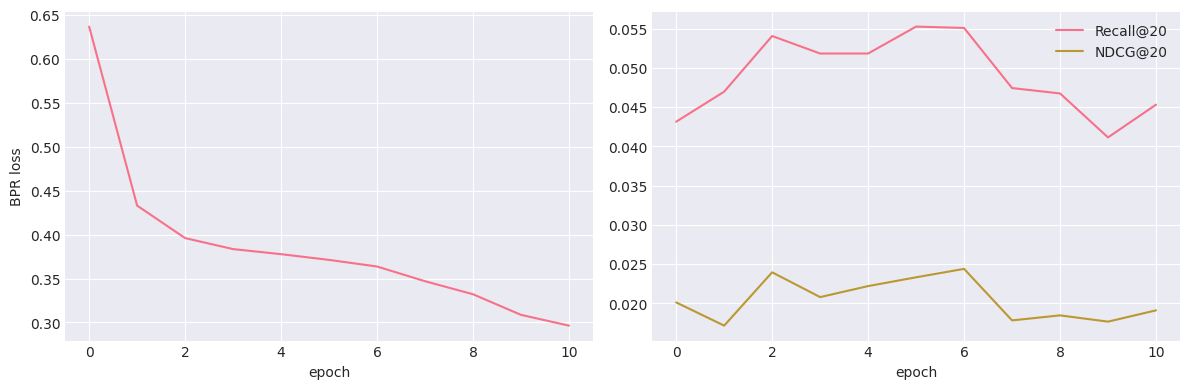

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['bpr'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BPR loss')
axes[1].plot(history['val_recall'], label='Recall@20')
axes[1].plot(history['val_ndcg'], label='NDCG@20')
axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()
